In [1]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings("ignore")

In [2]:
dataset=pd.read_csv("healthcare-dataset-stroke-data.csv")
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
dataset.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
dataset.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [16]:
dataset['age']=dataset['age'].astype('int64')

In [17]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if(dataset[columnName].dtype=='O'):
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [21]:
quan,qual=quanQual(dataset)

In [19]:
dataset[quan]

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,9046,67,0,1,228.69,36.600000,1
1,51676,61,0,0,202.21,28.893237,1
2,31112,80,0,1,105.92,32.500000,1
3,60182,49,0,0,171.23,34.400000,1
4,1665,79,1,0,174.12,24.000000,1
...,...,...,...,...,...,...,...
5105,18234,80,1,0,83.75,28.893237,0
5106,44873,81,0,0,125.20,40.000000,0
5107,19723,35,0,0,82.99,30.600000,0
5108,37544,51,0,0,166.29,25.600000,0


In [23]:
dataset[qual]

,gender,ever_married,work_type,Residence_type,smoking_status
0,Male,Yes,Private,Urban,formerly smoked
1,Female,Yes,Self-employed,Rural,never smoked
2,Male,Yes,Private,Rural,never smoked
3,Female,Yes,Private,Urban,smokes
4,Female,Yes,Self-employed,Rural,never smoked
...,...,...,...,...,...
5105,Female,Yes,Private,Urban,never smoked
5106,Female,Yes,Self-employed,Urban,never smoked
5107,Female,Yes,Self-employed,Rural,never smoked
5108,Male,Yes,Private,Rural,formerly smoked


In [7]:
ds_stroke=dataset[dataset['stroke']==1]
ds_stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
244,17739,Male,57,0,0,Yes,Private,Rural,84.96,36.7,Unknown,1
245,49669,Female,14,0,0,No,children,Rural,57.93,30.9,Unknown,1
246,27153,Female,75,0,0,Yes,Self-employed,Rural,78.80,29.3,formerly smoked,1
247,34060,Male,71,1,0,Yes,Self-employed,Rural,87.80,NaN,Unknown,1


#Fill the null values of bmi with its mean

In [8]:
dataset['bmi'].fillna(dataset['bmi'].mean(),inplace=True)

1. Total Stroke patients in the given dataset

In [9]:
Stroke_Count=len(dataset[dataset['stroke']==1])
print("The Number of Stroke Patients present in the given dataset is:",Stroke_Count)

The Number of Stroke Patients present in the given dataset is: 249


2. What is the minimum and maximum age of the stroke patients?

In [47]:
min_age=dataset[dataset['stroke']==1]['age'].min()
print("The minimum age of the stroke patients in the given dataset is:",min_age)

The minimum age of the stroke patients in the given dataset is: 1


In [46]:
max_age=dataset[dataset['stroke']==1]['age'].max()
print("The maximum age of the stroke patients in the given dataset is:",max_age)

The maximum age of the stroke patients in the given dataset is: 82


In [78]:
dataset.drop(dataset.columns[0],axis=1)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


3. Find the number of smokers in the dataset who are affected with stroke

In [64]:
stroke_smoker = dataset.query("stroke == 1 and smoking_status == 'smokes'")
str_smkr=len(stroke_smoker)
print("The number of smokers who are affected with stroke",str_smkr)

The number of smokers who are affected with stroke 42


4. Female and Male count of Stroke patients

In [66]:
fem_stroke=dataset.query("stroke==1 and gender=='Female'")
print("The number of female stroke patients in the given dataset:",len(fem_stroke))
mal_stroke=dataset.query("stroke==1 and gender=='Male'")
print("The number of male stroke patients in the given dataset:",len(mal_stroke))

The number of female stroke patients in the given dataset: 141
The number of male stroke patients in the given dataset: 108


5. How many Hyper tension people are affected with stroke?

In [68]:
bp_stroke=dataset.query("stroke==1 and hypertension==1")
print("The number hyper tension people affected with stroke:",len(bp_stroke))

The number hyper tension people affected with stroke: 66


6. How many heart patients are affected with stroke?

In [70]:
heart_stroke=dataset.query("stroke==1 and heart_disease==1")
print("The number of heart patients affected with stroke:",len(heart_stroke))

The number of heart patients affected with stroke: 47


7. How many patients who have heart disease and hypertension are affected with stroke?

In [72]:
bp_hrt_stroke=dataset.query("stroke==1 and heart_disease==1 and hypertension==1")
print("The number of patients who have heart disease and hyper tension are affected with stroke",len(bp_hrt_stroke))

The number of patients who have heart disease and hyper tension are affected with stroke 13


8. How many patients with glucose level more than 120 are affected with stroke?

In [73]:
sugar_stroke=dataset.query("stroke==1 and avg_glucose_level>120")
print("The number of sugar patients affected with stroke:",len(sugar_stroke))

The number of sugar patients affected with stroke: 102


9. How does hypertension increases the risk of stroke?

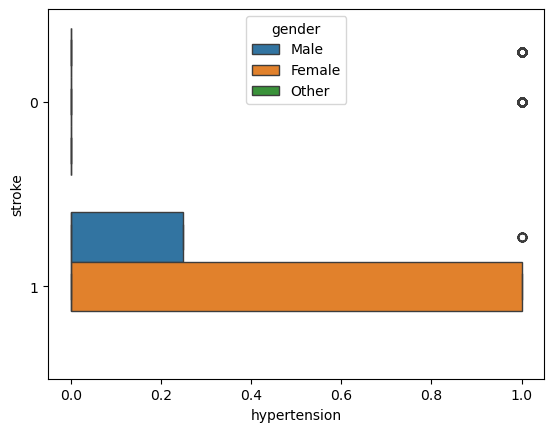

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
data=dataset
sns.boxplot(x="hypertension",y="stroke",hue="gender",data=data,orient='h')
plt.show()

10. Does the age factor increases the risk of stroke?

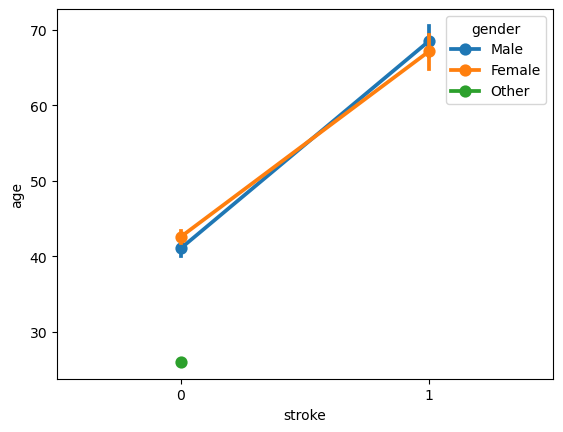

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
data=dataset
sns.pointplot(x="stroke",y="age",hue="gender",data=data)
plt.show()

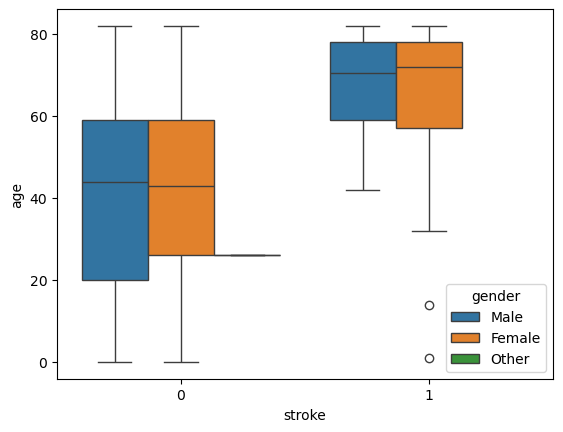

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
data=dataset
sns.boxplot(x="stroke",y="age",hue="gender",data=data)
plt.show()

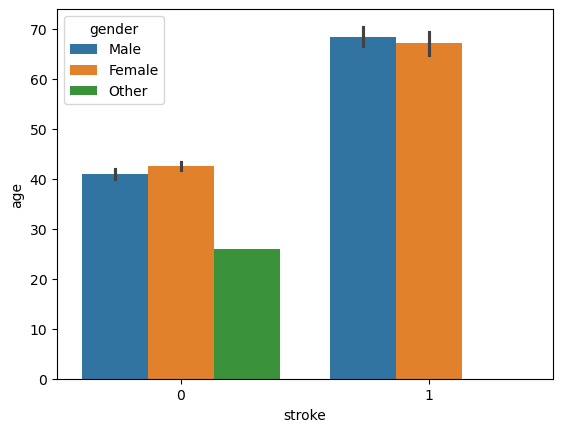

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
data=dataset
sns.barplot(x="stroke",y="age",hue="gender",data=data)
plt.show()

11. Does the glucose level the risk of stroke?

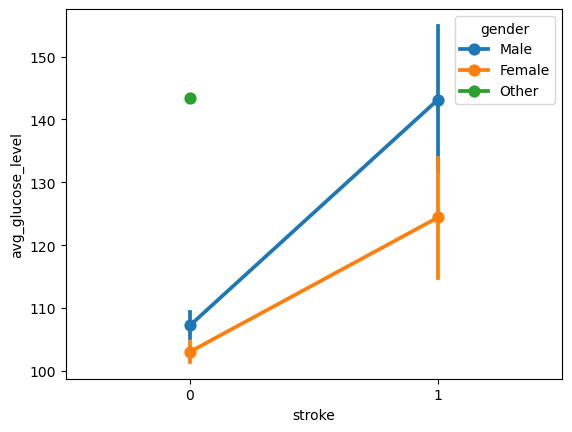

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
data=dataset
sns.pointplot(x="stroke",y="avg_glucose_level",hue="gender",data=data)
plt.show()